# Class 15 non-inertial-frame experiment 2

This notebook loads the second trajectory exported from Tracker and plots the measured path on a circular coordinate grid. Position units are centimeters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("Class15_experiment_2.txt")
data = np.loadtxt(data_path, skiprows=2)

t_s = data[:, 0]
x_cm = data[:, 1]
y_cm = data[:, 2]

print(f"Loaded {len(t_s)} points from {data_path}")
print(f"Time interval: {t_s[0]:.3f} to {t_s[-1]:.3f} s")
print(f"Initial point: ({x_cm[0]:.3f}, {y_cm[0]:.3f}) cm")
print(f"Final point:   ({x_cm[-1]:.3f}, {y_cm[-1]:.3f}) cm")

Loaded 7 points from Class15_experiment_2.txt
Time interval: 0.352 to 0.616 s
Initial point: (1.757, -3.687) cm
Final point:   (1.460, 2.821) cm


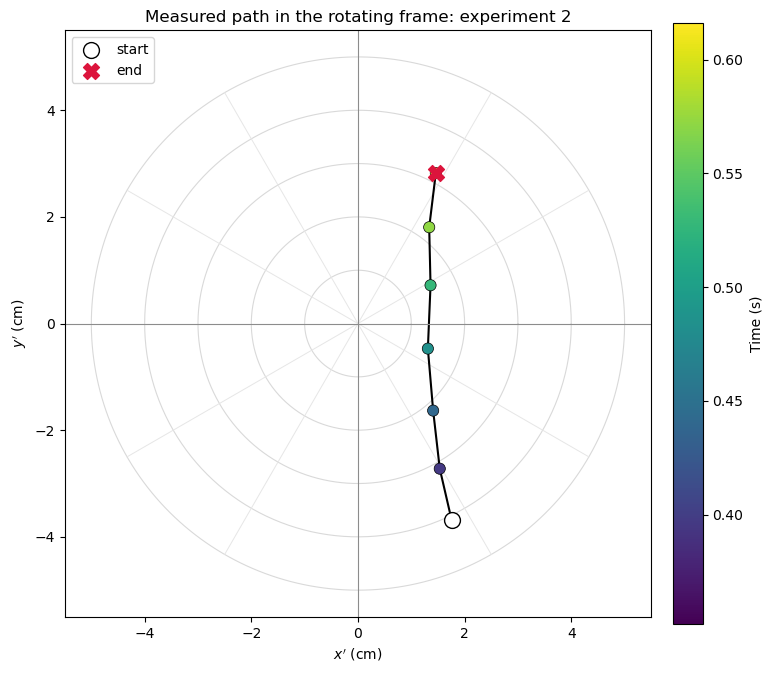

In [2]:
radius_cm = np.hypot(x_cm, y_cm)
plot_radius_cm = np.ceil(radius_cm.max())

fig, ax = plt.subplots(figsize=(8, 8))

# Circular grid rings centered on the rotating-frame origin
theta = np.linspace(0, 2 * np.pi, 500)
for radius in np.arange(1, plot_radius_cm + 1):
    ax.plot(
        radius * np.cos(theta),
        radius * np.sin(theta),
        color="0.85",
        linewidth=0.8,
        zorder=0,
    )

# Radial guides every 30 degrees
for angle in np.deg2rad(np.arange(0, 360, 30)):
    ax.plot(
        [0, plot_radius_cm * np.cos(angle)],
        [0, plot_radius_cm * np.sin(angle)],
        color="0.90",
        linewidth=0.7,
        zorder=0,
    )

points = ax.scatter(
    x_cm,
    y_cm,
    c=t_s,
    cmap="viridis",
    s=65,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)
ax.plot(x_cm, y_cm, color="black", linewidth=1.5, zorder=2)
ax.scatter(
    x_cm[0], y_cm[0], marker="o", s=130, facecolor="white",
    edgecolor="black", label="start", zorder=4
)
ax.scatter(
    x_cm[-1], y_cm[-1], marker="X", s=130, color="crimson",
    label="end", zorder=4
)

limit = plot_radius_cm + 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color="0.55", linewidth=0.8)
ax.axvline(0, color="0.55", linewidth=0.8)
ax.set_xlabel("$x'$ (cm)")
ax.set_ylabel("$y'$ (cm)")
ax.set_title("Measured path in the rotating frame: experiment 2")
ax.legend(loc="upper left")
colorbar = fig.colorbar(points, ax=ax, shrink=0.78, pad=0.03)
colorbar.set_label("Time (s)")
fig.tight_layout()
plt.show()